# Looped Transformer

## 理论

Looped Transformer 所有层共享相同的权重 $\theta$，每层的输入是前一层输出与初始输入的和：

$$
\begin{aligned}
h_0 &= \text{input} \\
h_l &= \text{TransformerBlock}(h_{l-1} + h_0| \theta) \quad \text{for } l=1,2,...,L
\end{aligned}
$$

### 截断损失函数

$$\text{Loss}=\min_{\theta} \mathbb{E}_P \left[ \frac{1}{b - b_0} \sum_{t = b_0}^{b} \frac{1}{k + 1} \sum_{i = 0}^{k} (Y_t(P^i | \theta) - f(x_{i+1}))^2 \right]$$
其中
- $\min_{\theta}$：这是我们在寻找一组最优的物理定律（模型参数 $\theta$）。
- $\mathbb{E}_P$：对所有生成的 Prompt 分布求期望。在统计物理中，这相当于求“系综平均”，即我们在无数种不同的初始条件（数据集）下测试这个定律是否普适。  
- $\frac{1}{b-b_0} \sum_{t=b_0}^{b}$：这是时间平均。$b$ 是总迭代次数，$T$ 是窗口大小，$b_0 = \max(b-T, 0)$。我们只关心系统演化到“稳态”附近的这段时间内(也就是$b_0$ 到 $b$ 的表现)，前面瞬态的误差我们不计较。  
- $\frac{1}{k+1} \sum_{i=0}^{k}$：这是空间/序列平均。也就是在给定不同长度的上下文 $P^i$ 时，模型预测下一个点的值与真实函数 $f(x_{i+1})$ 之间的均方误差。  
- $Y_t(P^i|\theta)$：在时间 $t$、给定历史信息 $P^i$ 和系统参数 $\theta$ 时，系统当前的状态输出。 

### 下游任务

- 数据生成方式：这篇论文解决的是纯粹的数学数据拟合问题。数据集是在训练循环中即时生成的浮点数向量。  
- 以最基础的 **线性回归（Linear Regression）** 为例：
  - 维度设定：问题维度 $d=20$，上下文样本数 $k=40$。  
  - 生成逻辑：每次迭代前，随机采样一个真实的参数 $w \sim \mathcal{N}(0, I_d)$。  
  - 采样输入：生成 $k+1$ 个输入样本（包含测试样本） $x_i \sim \mathcal{N}(0, I_d)$。  
  - 计算标签：$y_i = w^T x_i$。  
  - 拼接成 Prompt：最终喂给模型的序列 $P$ 是一个交替的序列 $(x_1, y_1, x_2, y_2, \dots, x_k, y_k, x_{test}, y_{dummy})$。
- 线性回归可以进一步改成非线性回归（比如 ReLU与Linear 叠加），或者更复杂的物理系统。

#### 把 Prompt 映射到高维 Embedding 空间

**双通道映射与“拉链式”交织**

由于 `x` 和 `y` 代表不同的物理量（一个是空间坐标/特征，一个是目标观测值），我们需要赋予它们独立的投影空间：

1.	定义两个独立的线性层：
```python
read_in_x = nn.Linear(20, 256)
read_in_y = nn.Linear(1, 256)
```
2.	把前`k`个 `x_i` 丢给 `read_in_x`，变成张量 `X_emb`，形状为 `[batch, k, 256]`。
3.	把前`k`个 `y_i` 丢给 `read_in_y`，变成张量 `Y_emb`，形状为 `[batch, k, 256]`。
4.	像拉拉链一样，在`seq_len`维度上把`X_emb`、`Y_emb`交织（Interleave）起来，拼接成最终长度为 `2k` 的提示向量 `P`。

在工程实现中，我们在 $x_{test}$ 后填充了一个 $y_{dummy}$（如 0），使实际拼接长度变为 `2k+2`（偶数）。因此，真正对 $x_{test}$ 的预测结果位于输出序列的倒数第二个位置，即索引 `[-2]` 处。

## 代码

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F

### 绝对位置编码(APE, Absolute Position Encoding)

In [34]:
class APE(nn.Module):
    def __init__(self, d_model, max_seq_len=4096, b=10000):
        super().__init__()
        theta_i = 1 / (b ** (torch.arange(0, d_model, 2).float() / d_model)) # [d_model/2]
        m = torch.arange(max_seq_len).float() # [max_seq_len]
        m_theta_i = torch.outer(m, theta_i) # [max_seq_len, d_model/2]
        # APE 核心：直接生成一个完整的 pe 矩阵，偶数维度放 sin，奇数维度放 cos
        stacked=torch.stack((torch.sin(m_theta_i), torch.cos(m_theta_i)), dim=-1) # [max_seq_len, d_model/2, 2]
        pe=stacked.flatten(1,2) # [max_seq_len, d_model]
        self.register_buffer('pe', pe.unsqueeze(0)) # shape: [1, max_seq_len, d_model]

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        return x + self.pe[:, :x.shape[1], :]

#### Learned APE

In [35]:
class LearnedAPE(nn.Module):
    def __init__(self, d_model, max_seq_len=4096):
        super().__init__()
        self.pe = nn.Embedding(max_seq_len, d_model) 

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        seq_len = x.shape[1]
        positions = torch.arange(seq_len, device=x.device)
        return x + self.pe(positions).unsqueeze(0)

#### 自创：Multi-Scale Untied Positional Encoding (MS-UPE)

In [36]:
class MS_UPE(nn.Module):
    def __init__(self,num_heads, d_k, max_seq_len = 4096, b_0=10000, head_ratio=2):
        super().__init__()
        b=(b_0*(head_ratio**(torch.arange(0, num_heads)))).float() # [num_heads]
        # \theta_i = b^{-\frac{2i}{d}}, \quad i \in \{0,1,\dots,\frac{d}{2}-1\} 
        theta_i = 1/(b.unsqueeze(1)**(torch.arange(0,d_k,2).float()/d_k).unsqueeze(0))  # [num_heads, d_k/2]
        m = torch.arange(max_seq_len).float()  # m = [0,1,...,seq_len-1]
        m_theta_i = torch.einsum('m,hk->hmk', m, theta_i)  # [num_heads, seq_len, d_k/2]
        pe = torch.cat((torch.cos(m_theta_i), torch.sin(m_theta_i)), dim=-1)  # [num_heads, seq_len, d_k] 
        self.register_buffer('pe', pe[None, :, :, :])  # 好处：pe不需要更新参数，注册为buffer后会自动放到正确的设备上

    def forward(self, x): # 适用于Q、K (V不需要位置编码!)
        # x: [batch_size, num_heads, seq_len, d_k]
        seq_len = x.shape[2]
        pe = self.pe[:, :, :seq_len, :]  # [1, num_heads, seq_len, d_k] 
        x_out = x + pe
        return x_out

### 去掉 RoPE 的 Multi-Head Attention

注：`APE` 应该加在 `ToyModel` 上而不是 `TransformerBlock` 上，因为我们只需要最开头输入处编码位置，而不是叠加 `num_blocks` 次。

In [37]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, d_model, max_seq_len=4096):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        # 维度属性
        self.num_heads = num_heads
        self.d_model = d_model
        self.d_k = d_model // num_heads
        # 权重矩阵
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False) 
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        # 因果掩码
        tril = torch.tril(torch.ones(max_seq_len, max_seq_len)).bool() # torch.tril (triangular lower)提取下三角元素，并把上三角元素置0
        mask = torch.zeros(max_seq_len, max_seq_len).masked_fill(~tril, float('-inf')) # 下三角元素置0，上三角元素置-inf
        self.register_buffer('mask', mask[None, None, :, :])  # [1, 1, seq_len, seq_len]

    def forward(self, x): # x: [batch_size, seq_len, d_model]
        # 线性投影与分头
        batch_size, seq_len, _ = x.shape
        Q = self.W_Q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)  # [batch_size, num_heads, seq_len, d_k]
        K = self.W_K(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)  # 交换(1, 2)是因为之后softmax时要进行矩阵乘法(只乘后两维)
        V = self.W_V(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)  # 在seq_len维度上分配注意力
        # 缩放点积注意力与因果掩码 Causal Masking
        ## Query-Key 点积计算注意力得分
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)  # [batch_size, num_heads, seq_len, seq_len]
        ## 因果掩码和 softmax 计算注意力权重
        Attention = F.softmax(scores + self.mask[..., :seq_len, :seq_len], dim=-1)  # [batch_size, num_heads, seq_len, seq_len]
        self.captured_attention = Attention  # **新增**：捕获注意力矩阵，用hook记录下来，方便后续分析
        ## 乘以 Value 完成加权求和
        Out = torch.matmul(Attention, V)  # [batch_size, num_heads, seq_len, d_k]
        # 多头拼接并乘以输出矩阵(必须先内存连续化(contiguous)再view，否则会报错)
        Out = Out.transpose(1, 2).contiguous().view(batch_size, seq_len, -1)  # [batch_size, seq_len, d_model]
        H = self.W_O(Out)  # [batch_size, seq_len, d_model]
        return H

### SwiGLU 和 单个 Transformer Block 架构不变

In [38]:
class SwiGLU(nn.Module):
    def __init__(self,d_model,d_hidden):
        super().__init__()
        self.W = nn.Linear(d_model,d_hidden,bias=False)
        self.V = nn.Linear(d_model,d_hidden,bias=False)
        self.W2 = nn.Linear(d_hidden,d_model,bias=False)
    def forward(self,x):
        x1 = F.silu(self.W(x))
        x2 = self.V(x)
        x_out = self.W2(x1 * x2)
        return x_out

In [39]:
class TransformerBlock(nn.Module):
    def __init__(self, num_heads, d_model, max_seq_len=4096, multiplier=4, norm_type='layernorm', ffn_type='gelu'):
        super().__init__()
        if norm_type == 'rmsnorm':
            self.norm1 = nn.RMSNorm(d_model)  # 第一次归一化
            self.norm2 = nn.RMSNorm(d_model)  # 第二次归一化
        elif norm_type == 'layernorm':
            self.norm1 = nn.LayerNorm(d_model)  # 第一次归一化
            self.norm2 = nn.LayerNorm(d_model)  # 第二次归一化
        self.attention = MultiHeadAttention(num_heads, d_model, max_seq_len=max_seq_len)
        if ffn_type == 'swiglu':
            self.ffn = SwiGLU(d_model, d_model * multiplier)
        elif ffn_type == 'gelu':
            self.ffn = nn.Sequential(
                nn.Linear(d_model, d_model * multiplier),
                nn.GELU(),
                nn.Linear(d_model * multiplier, d_model)
            )
    
    def forward(self, x):
        # 第一次归一化 Pre-Norm
        x_norm1 = self.norm1(x)
        # 全局信息交互 Multi-Head Attention (MHA)
        h = self.attention(x_norm1)
        # 第一次残差连接
        x1 = x + h
        # 第二次归一化
        x_norm2 = self.norm2(x1)
        # 前馈网络 Feed-Forward Network (FFN) 
        x_out = self.ffn(x_norm2)
        # 第二次残差连接
        x2 = x1 + x_out
        return x2

### 保留 Attention Probe

In [40]:
class AttentionProbe:
    def __init__(self):
        self.captured_data = []
    def __call__(self, module, input, output):
        attention = module.captured_attention.detach().cpu().numpy() 
        self.captured_data.append(attention)
    def reset(self):
        self.captured_data = [] 

### Toy Model: Looped Transformer

In [41]:
class ToyModel(nn.Module):
    def __init__(self, num_blocks, num_heads, d_model, max_seq_len=4096, 
                 norm_type='layernorm', ffn_type='gelu', pe_type='learned_ape',
                 loop=True):
        super().__init__()
        self.loop = loop
        if loop:
            self.transformer_block = TransformerBlock(num_heads, d_model, max_seq_len=max_seq_len, norm_type=norm_type, ffn_type=ffn_type) # 这里保证了各层权重始终相同
            self.probe = AttentionProbe()
            self.transformer_block.attention.register_forward_hook(self.probe)
            self.captured_attention = None
        else:
            self.transformer_blocks = nn.ModuleList([
                TransformerBlock(num_heads, d_model, max_seq_len=max_seq_len, norm_type=norm_type, ffn_type=ffn_type) 
                for _ in range(num_blocks)
            ])
            self.probe = nn.ModuleList([AttentionProbe() for _ in range(num_blocks)])
            for block, probe in zip(self.transformer_blocks, self.probe):
                block.attention.register_forward_hook(probe)
        if pe_type == 'ape':
            self.ape = APE(d_model, max_seq_len=max_seq_len) # 位置编码只需要加在最开始输入处
        elif pe_type == 'learned_ape':
            self.ape = LearnedAPE(d_model, max_seq_len=max_seq_len)
        self.num_blocks = num_blocks
        self.num_heads = num_heads
        self.d_model = d_model
        self.max_seq_len = max_seq_len

    def forward(self, x_0, num_eff=15): 
        # num_eff 是需要加入误差计算的有效层数，也即理论公式中的 T
        # x 的形状为 [batch_size, seq_len, d_model]
        x_0 = self.ape(x_0) # 位置编码只加在最开始输入处
        x = x_0
        b_0 = max(0, self.num_blocks - num_eff) # 计算需要加入误差计算的有效层数对应的起始层索引
        outputs = []
        if self.loop:
            self.probe.reset() # 每次前向传播前重置捕获的数据，避免混淆不同次前向传播的注意力矩阵
            for i in range(self.num_blocks):
                if i == b_0:
                    x= x.detach() # 释放前面的计算图
                    x.requires_grad_(True)
                x = self.transformer_block(x+x_0)
                if i >= b_0: 
                    outputs.append(x) 
            self.captured_attention = list(self.probe.captured_data) # 显式copy一份数据，避免后续被修改
        else:
            for probe in self.probe:
                probe.reset()
            for i, block in enumerate(self.transformer_blocks):
                if i == b_0:
                    x= x.detach() # 释放前面的计算图
                    x.requires_grad_(True)
                x = block(x+x_0)
                if i >= b_0: 
                    outputs.append(x)
            self.captured_attention = [probe.captured_data for probe in self.probe]
        outputs = torch.stack(outputs, dim=1) # [batch_size, num_eff, seq_len, d_model]
        return outputs

### Downstream Task: Linear Regression

#### 转换头

In [42]:
class RegressionHead(nn.Module):
    def __init__(self, d_model, d_x, d_y=1):
        super().__init__()
        self.read_in_x = nn.Linear(d_x, d_model)
        self.read_in_y = nn.Linear(d_y, d_model)
    def forward(self, x_data, y_data):
        # k相当于seq_len的一半，因为x和y交织在一起，所以总的seq_len是2k
        # x_data: [batch_size, k, d_x]
        # y_data: [batch_size, k, d_y]
        x_emb = self.read_in_x(x_data)  # [batch_size, k, d_model]
        y_emb = self.read_in_y(y_data)  # [batch_size, k, d_model]
        # 交织成 (x_1, y_1, x_2, y_2, ..., x_k, y_k)
        stacked = torch.stack((x_emb, y_emb), dim=2)  # [batch_size, k, 2, d_model]
        Prompt = stacked.flatten(1,2)  # [batch_size, 2k, d_model]
        return Prompt

#### 损失函数

In [43]:
class PredictionLoss(nn.Module):
    def __init__(self, d_model, d_y=1, loss_type='mse'):
        super().__init__()
        self.read_out = nn.Linear(d_model, d_y)
        if loss_type == 'mse':
            self.loss_fn = nn.MSELoss()
        elif loss_type == 'l1':
            self.loss_fn = nn.L1Loss()

    def forward(self, outputs, y_true, is_eval=False): 
        # outputs:[batch_size, num_eff, seq_len, d_model]
        # y_true: [batch_size, seq_len/2, 1]
        if is_eval:
            y_outputs = outputs[:, -1, -2, :] # 只取最后一层的最后一个位置的输出作为预测值
            y_pred_final = self.read_out(y_outputs) # [batch_size, d_y]
            return y_pred_final
        y_outputs = outputs[:, :, 0::2, :] # [batch_size, num_eff, seq_len/2, d_model]
        y_preds = self.read_out(y_outputs) # [batch_size, num_eff, seq_len/2, d_y]
        loss = self.loss_fn(y_preds, y_true.unsqueeze(1).expand_as(y_preds)) # [batch_size, num_eff, seq_len/2, d_y]
        return loss

#### 拼装

In [44]:
class RegressionSolver(nn.Module):
    def __init__(self, num_blocks, num_heads, d_model, d_x, d_y, max_seq_len, 
                 norm_type='layernorm', ffn_type='gelu', pe_type='learned_ape', loop=True, loss_type='mse'):
        super().__init__()
        self.toy_model = ToyModel(num_blocks, num_heads, d_model, max_seq_len, norm_type=norm_type, ffn_type=ffn_type, pe_type=pe_type, loop=loop)
        self.head = RegressionHead(d_model, d_x, d_y)
        self.loss_fn = PredictionLoss(d_model, d_y, loss_type=loss_type)
        
    def forward(self, x_data, y_data, num_eff, is_eval=False):
        Prompt = self.head(x_data, y_data) # [batch_size, seq_len, d_model]
        outputs = self.toy_model(Prompt, num_eff) # [batch_size, num_eff, seq_len, d_model]
        output = self.loss_fn(outputs, y_data, is_eval=is_eval)
        return output

### Experiment

In [45]:
def linear_data_generator(batch_size, seq_len, d_x, d_y, device='cpu'):
    w = torch.randn(batch_size, d_x, d_y, device=device)  # 真实线性函数 w
    x_data = torch.randn(batch_size, seq_len//2, d_x, device=device)  # 输入特征 x
    y_data = x_data @ w  # 计算标签 y = x @ w
    return x_data, y_data

In [46]:
def dataloader(batch_size=64, seq_len=80, d_x=20, d_y=1, device='cpu', data_type='linear'):
    while True:
        if data_type == 'linear':
            yield linear_data_generator(batch_size, seq_len, d_x, d_y, device=device)

In [47]:
class LoopedTransformerExperiment:
    def __init__(self, num_blocks, num_heads=8, d_model=256, lr=1e-4, max_seq_len=4096, d_x=20, d_y=1, 
                 norm_type='layernorm', ffn_type='gelu', pe_type='learned_ape', optimizer_type='adam', loop=True, loss_type='mse'):
        # 设备选择：优先使用 MPS（适用于 Apple Silicon），其次是 CUDA（适用于 NVIDIA GPU），最后退回 CPU
        if torch.backends.mps.is_available():
            self.device = torch.device("mps")
        elif torch.cuda.is_available():
            self.device = torch.device("cuda")
        else:
            self.device = torch.device("cpu")
        print(f"Experiment initialized. Using device: {self.device}")
        # 模型和优化器
        self.model = RegressionSolver(num_blocks, num_heads, d_model, d_x=d_x, d_y=d_y, max_seq_len=max_seq_len, 
                                      norm_type=norm_type, ffn_type=ffn_type, pe_type=pe_type, loop=loop, loss_type=loss_type).to(self.device)
        if optimizer_type == 'adam':
            self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        elif optimizer_type == 'sgd':
            self.optimizer = torch.optim.SGD(self.model.parameters(), lr=lr)
        self.d_x = d_x
        self.d_y = d_y 
        self.num_blocks = num_blocks
    
    def train(self, batch_size=64, seq_len=80, epochs=20, num_eff=None, data_type='linear'):
        # x_data: [batch_size, k, d_x]
        # y_data: [batch_size, k, d_y]
        self.data_loader = dataloader(batch_size, seq_len, self.d_x, self.d_y, device=self.device, data_type=data_type)
        self.loss_history = []
        auto=(num_eff is None) # 如果没有指定 num_eff，就启用自动调整机制
        for epoch in range(epochs):
            self.optimizer.zero_grad()
            if auto:
                # num_eff 的设定：随着训练的进行，逐渐增加参与误差计算的有效层数
                num_eff = min(epoch+1, max(self.num_blocks-5, 5)) 
            x_data, y_data = next(self.data_loader) # 从数据加载器中获取一个批次的数据
            loss = self.model(x_data, y_data, num_eff=num_eff, is_eval=False) # 前向传播计算损失 [batch_size, num_eff, seq_len/2, d_y]
            loss = loss.mean()  # 对所有维度求平均得到一个标量损失值
            loss.backward()  # 反向传播计算梯度
            self.optimizer.step()  # 更新模型参数
            self.loss_history.append(loss.item())  # 记录损失值
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, num_eff: {num_eff}")

    def evaluate(self, batch_size=64, seq_len=80, data_type='linear', loss_type='mse'):
        self.model.eval()
        with torch.no_grad():
            # 在评估模式下，直接使用所有层的输出进行预测(因为已经no_grad了，所以不需要防止梯度爆炸了)
            x_eval, y_eval = next(dataloader(batch_size, seq_len+1, self.d_x, self.d_y, device=self.device, data_type=data_type))
            y_pred = self.model(x_eval, y_eval, num_eff=self.num_blocks, is_eval=True) # [batch_size, d_y]
            if loss_type == 'mse':
                mse=F.mse_loss(y_pred, y_eval[:, -1, :])
                print(f"MSELoss: {mse:.4f}") # 计算预测值与真实值之间的均方误差
            elif loss_type == 'l1':
                l1=F.l1_loss(y_pred, y_eval[:, -1, :])
                print(f"L1Loss: {l1:.4f}") 
        return y_pred

Experiment initialized. Using device: mps
Epoch 1/20, Loss: 93.0781, num_eff: 15
Epoch 2/20, Loss: 75.4753, num_eff: 15
Epoch 3/20, Loss: 72.5929, num_eff: 15
Epoch 4/20, Loss: 62.7761, num_eff: 15
Epoch 5/20, Loss: 58.6597, num_eff: 15
Epoch 6/20, Loss: 50.8077, num_eff: 15
Epoch 7/20, Loss: 45.3426, num_eff: 15
Epoch 8/20, Loss: 40.0331, num_eff: 15
Epoch 9/20, Loss: 33.4742, num_eff: 15
Epoch 10/20, Loss: 31.7708, num_eff: 15
Epoch 11/20, Loss: 29.9054, num_eff: 15
Epoch 12/20, Loss: 29.3184, num_eff: 15
Epoch 13/20, Loss: 26.8656, num_eff: 15
Epoch 14/20, Loss: 24.0610, num_eff: 15
Epoch 15/20, Loss: 25.2200, num_eff: 15
Epoch 16/20, Loss: 22.8198, num_eff: 15
Epoch 17/20, Loss: 23.7630, num_eff: 15
Epoch 18/20, Loss: 22.6003, num_eff: 15
Epoch 19/20, Loss: 21.1701, num_eff: 15
Epoch 20/20, Loss: 22.5447, num_eff: 15


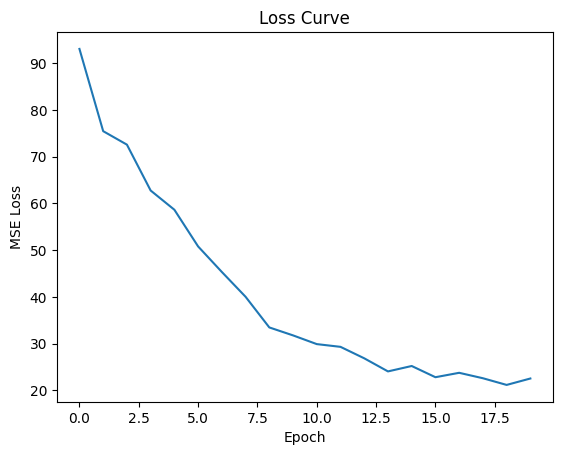

In [49]:
experiment = LoopedTransformerExperiment(num_blocks=20, 
                                         num_heads=8, 
                                         d_model=256, 
                                         lr=1e-4, 
                                         max_seq_len=4096, 
                                         d_x=20, 
                                         d_y=1,
                                         norm_type='layernorm', 
                                         ffn_type='gelu', 
                                         pe_type='learned_ape', 
                                         loop=True, 
                                         loss_type='mse')
experiment.train(batch_size=64, 
                 seq_len=80, 
                 epochs=20, 
                 num_eff=15, 
                 data_type='linear')
# 绘制Loss下降曲线
import matplotlib.pyplot as plt
plt.plot(experiment.loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss Curve')
plt.show()